1.1. Problēmas apraksts
Mēs strādājam ar e-komercijas uzņēmuma datiem, lai analizētu tiešsaistes pircēju uzvedību. Mūsu mērķis ir prognozēt, vai apmeklētājs savas sesijas laikā veiks pirkumu (darījumu), pamatojoties uz dažādiem parametriem, piemēram, apmeklēto lapu skaitu un laiku, kas pavadīts vietnē. Šāda prognoze palīdzēs uzņēmumam optimizēt mārketinga stratēģijas un uzlabot klientu noturēšanu.

1.2. ML tipa identificēšana
Vai ir “pareizā atbilde”? Jā, datos ir kolonna Revenue (True/False).

Kad mēs gribam atbildi? Katram jaunam klientam (sesijai).

ML veids: Supervised Learning (uzraudzītā mācīšanās).

Apakštips: Classification (klasifikācija), jo rezultāts ir binārs (pirks vai nepirks).

1.3. Target un Features
Target mainīgais: Revenue

Features (Iezīmes):

Skaitliskie: Administrative_Duration, Informational_Duration, ProductRelated_Duration, BounceRates, ExitRates, PageValues.

Kategoriskie: Month, VisitorType, Weekend, SpecialDay.

In [1]:
# 2.1. Bibliotēkas un imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Iestatījumi vizualizācijām
plt.style.use('ggplot') # Colab vidē 'seaborn-v0_8-darkgrid' var nestrādāt visos gadījumos, ggplot ir droša izvēle
sns.set_palette("husl")

print("✓ Visas bibliotēkas ielādētas veiksmīgi")

# 2.2. Datu ielāde
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopas forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
df.head()

✓ Visas bibliotēkas ielādētas veiksmīgi
Datu kopas forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
# 2.3. un 3.1. Datu izpēte un trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())

# Tā kā UCI datu kopa parasti ir tīra, pārbaudīsim vai tiešām ir 0
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("\n✓ Trūkstošo vērtību nav — dati ir tīri!")
else:
    print(f"\nBrīdinājums: Atrastas {total_missing} trūkstošas vērtības.")

Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

✓ Trūkstošo vērtību nav — dati ir tīri!


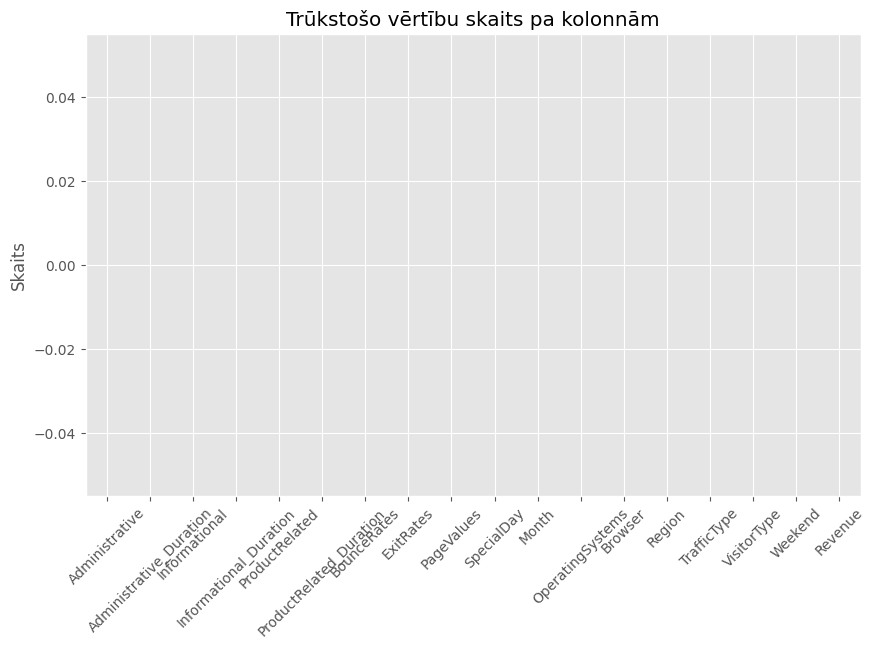

✓ Trūkstošo vērtību nav — dati ir tīri!


In [3]:
# 3.1. Vizualizē trūkstošās vērtības
missing = df.isnull().sum()
missing = missing[missing >= 0].sort_values(ascending=False) # Parādām visas kolonnas

plt.figure(figsize=(10, 6))
missing.plot(kind='bar', color='skyblue')
plt.title('Trūkstošo vērtību skaits pa kolonnām')
plt.ylabel('Skaits')
plt.xticks(rotation=45)
plt.show()

print("✓ Trūkstošo vērtību nav — dati ir tīri!")

Paskaidrojums par trūkstošajām vērtībām:
Šajā datu kopā trūkstošo vērtību nav. Tomēr, ja tādas būtu, skaitliskajām kolonnām es izmantotu mediānu (lai mazinātu izlecēju ietekmi), bet kategoriskajām kolonnām – modu (biežāk sastopamo vērtību), lai saglabātu datu dabisko sadalījumu.

In [4]:
# 4.1. Boolean kolonnas (True/False) konvertējam uz 0/1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# 4.2. One-Hot Encoding kategorijām ar vairākām vērtībām (Month, VisitorType)
# drop_first=True palīdz izvairīties no "dummy variable trap"
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

print(f"✓ Kodēšana pabeigta. Jaunā datu kopas forma: {df.shape}")
print(f"Datu tipi pēc apstrādes:\n{df.dtypes.value_counts()}")

✓ Kodēšana pabeigta. Jaunā datu kopas forma: (12330, 27)
Datu tipi pēc apstrādes:
bool       11
int64       9
float64     7
Name: count, dtype: int64


Kodēšanas metožu izvēle:

Label Encoding (0/1): Izmantots binārajām kolonnām Weekend un Revenue, jo tām ir tikai divi iespējamie stāvokļi.  

One-Hot Encoding: Izmantots kolonnām Month un VisitorType, jo tām ir vairākas kategorijas bez noteiktas secības. Tas novērš situāciju, kur modelis kļūdaini domātu, ka "May" ir lielāks vai svarīgāks par "Feb" tikai tāpēc, ka tam piešķirts lielāks skaitlis.

In [5]:
# 5.1. Atlasi skaitliskās kolonnas normalizācijai (izņemot target 'Revenue' un tikko izveidotās dummy kolonnas)
# Parasti normalizē oriģinālās skaitliskās kolonnas
numeric_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("✓ Normalizācija pabeigta.")
print("\nStatistika pēc normalizācijas (vidējai vērtībai jābūt tuvu 0):")
print(df[numeric_cols].mean().round(2))

✓ Normalizācija pabeigta.

Statistika pēc normalizācijas (vidējai vērtībai jābūt tuvu 0):
Administrative            -0.0
Administrative_Duration    0.0
Informational             -0.0
Informational_Duration    -0.0
ProductRelated             0.0
ProductRelated_Duration   -0.0
BounceRates               -0.0
ExitRates                  0.0
PageValues                 0.0
SpecialDay                -0.0
dtype: float64


✓ Jauna iezīme 'TotalDuration' izveidota.
Datu kopas forma tagad: (12330, 28)


/tmp/ipykernel_3728/2144039231.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Revenue', y='TotalDuration', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_3728/2144039231.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Nav pirkuma', 'Ir pirkums'])
/tmp/ipykernel_3728/2144039231.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='TotalDuration', data=df, ax=axes[1], palette='magma')
/tmp/ipykernel_3728/2144039231.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

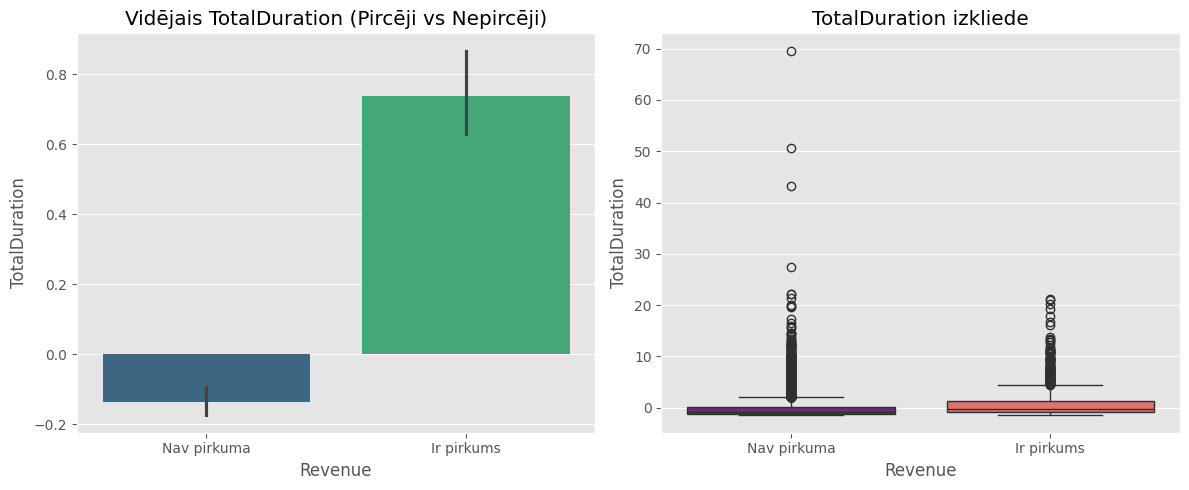

In [6]:
# 6.1. Jaunas iezīmes izveide
# Summējam visas laika kolonnas (tās jau ir normalizētas, tāpēc mērogs ir vienāds)
df['TotalDuration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

print(f"✓ Jauna iezīme 'TotalDuration' izveidota.")
print(f"Datu kopas forma tagad: {df.shape}")

# 6.3. Vizualizācija: Salīdzinājums starp pircējiem un nepircējiem
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vidējais kopējais laiks
sns.barplot(x='Revenue', y='TotalDuration', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Vidējais TotalDuration (Pircēji vs Nepircēji)')
axes[0].set_xticklabels(['Nav pirkuma', 'Ir pirkums'])

# Boxplot izkliedei
sns.boxplot(x='Revenue', y='TotalDuration', data=df, ax=axes[1], palette='magma')
axes[1].set_title('TotalDuration izkliede')
axes[1].set_xticklabels(['Nav pirkuma', 'Ir pirkums'])

plt.tight_layout()
plt.show()

Paskaidrojums par jauno iezīmi:

Kas tas ir? TotalDuration ir kopējais laiks, ko lietotājs pavadījis visās tīmekļa vietnes sadaļās vienas sesijas laikā.  

Kāpēc tas ir noderīgi? Biznesa loģika liecina, ka pircēji, kuri vietnē pavada vairāk laika, biežāk veic pirkumu. Modelim viena kopēja laika kolonna var būt spēcīgāks signāls nekā trīs atsevišķas, mazākas laika vērtības.

In [7]:
# 7.1. Datu saglabāšana
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")

# Pārbaude
df_check = pd.read_csv(output_path)
print(f"Pārbaude: Faila forma ir {df_check.shape}")

✓ Datu kopa saglabāta: shoppers_clean.csv
Pārbaude: Faila forma ir (12330, 28)


In [8]:
# 8.1. Definējam X (features) un y (target)
# Target ir 'Revenue' kolonna, X ir viss pārējais
y = df['Revenue']
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

# 8.2. Sadali datus treniņa un testa kopās
# Izmantojam 80% trenēšanai un 20% testēšanai
# stratify=y nodrošina vienādu klašu sadalījumu abās kopās
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("-" * 30)
print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā (%):\n{y_train.value_counts(normalize=True).round(3) * 100}")

Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%
------------------------------
Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā (%):
Revenue
0    84.5
1    15.5
Name: proportion, dtype: float64


Paskaidrojums par datu sadali:

Kāpēc stratify=y? Tā kā pirkumu (Revenue=1) ir daudz mazāk nekā sesiju bez pirkuma, stratify nodrošina, ka gan treniņa, gan testa datos pirkumu proporcija saglabājas tāda pati kā oriģinālajā datu kopā.  

Kāpēc 80/20 sadalījums? Tas ir optimāls līdzsvars: 80% datu ir pietiekami, lai modelis iemācītos likumsakarības, savukārt 20% testa datu ir pietiekami liela izlase, lai mēs varētu uzticēties pārbaudes rezultātiem.

9. uzdevums: Trenē trīs klasifikācijas modeļus:

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 9.1. Decision Tree (Lēmumu koks)
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

# 9.2. Random Forest (Nejaušais mežs)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("\n=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

# 9.3. Logistic Regression (Loģistiskā regresija)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("\n=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466


=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82 

10. uzdevums: Salīdzini modeļus un vizualizē rezultātus
Šis solis palīdzēs saprast, kurš modelis ir visprecīzākais. Mēs izmantosim F1 score, jo mūsu dati ir nesabalansēti (maz pirkumu pret daudz sesijām).

F1 Scores:
Decision Tree: 0.632
Random Forest: 0.636
Logistic Regression: 0.482


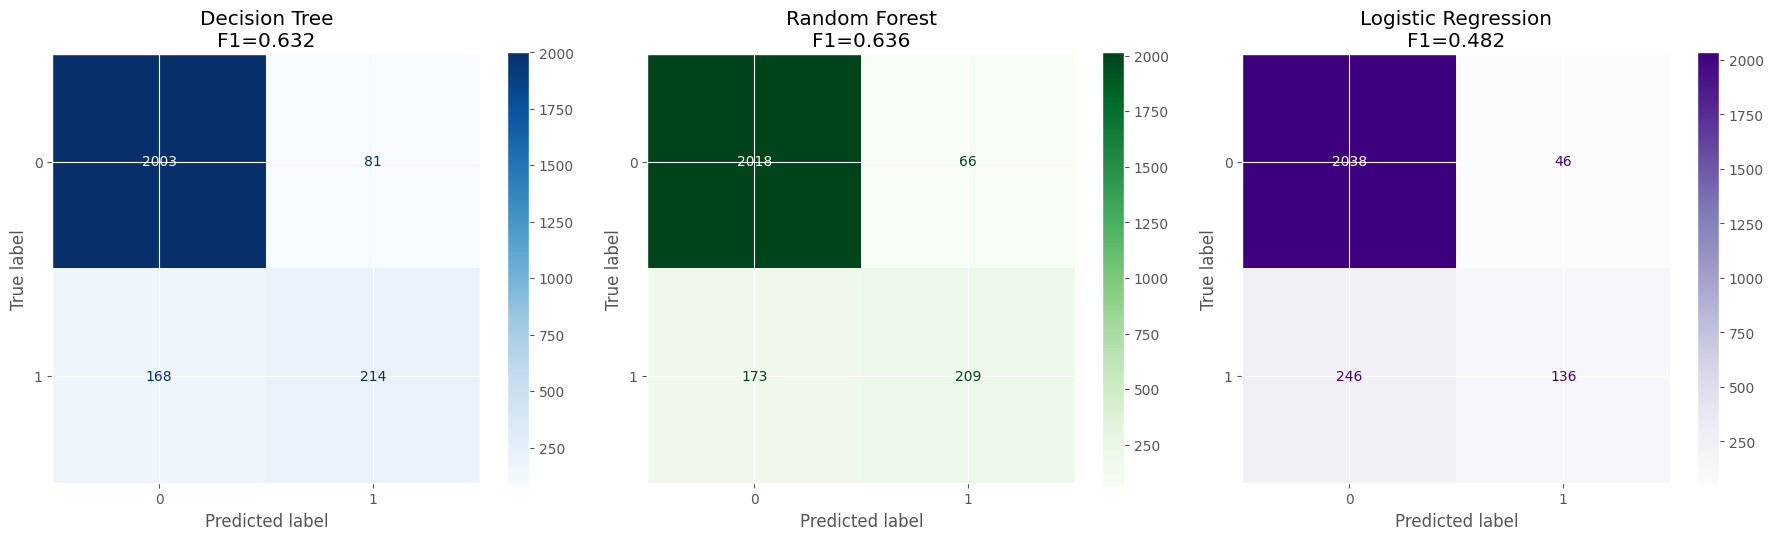

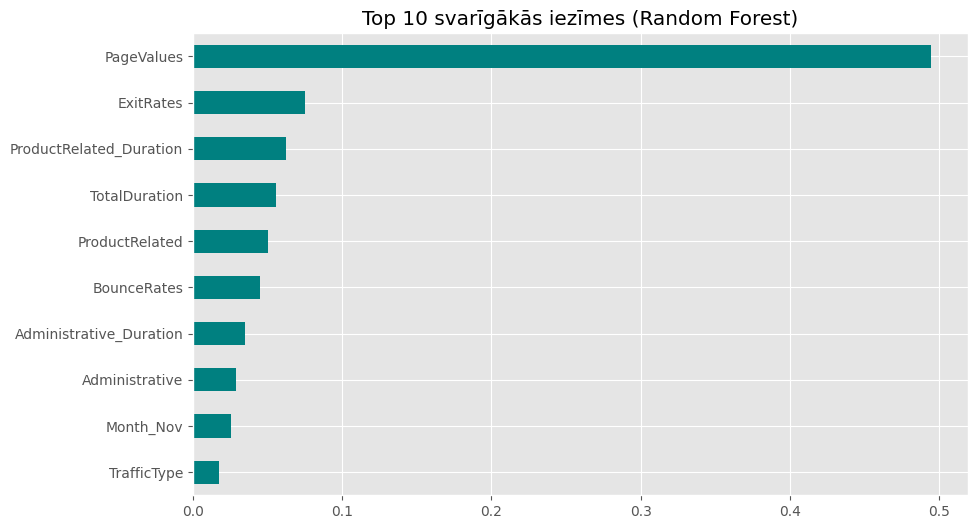

In [10]:
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# 10.1. F1 score salīdzinājums
dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"F1 Scores:\nDecision Tree: {dt_f1:.3f}\nRandom Forest: {rf_f1:.3f}\nLogistic Regression: {lr_f1:.3f}")

# 10.2. Confusion matrices blakus
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred, cmap='Blues', ax=axes[0])
axes[0].set_title(f'Decision Tree\nF1={dt_f1:.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest\nF1={rf_f1:.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, cmap='Purples', ax=axes[2])
axes[2].set_title(f'Logistic Regression\nF1={lr_f1:.3f}')

plt.tight_layout()
plt.show()

# 10.3. Feature importance (Kuras iezīmes ir vissvarīgākās?)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

Secinājumi par modeļu darbībuLabākais modelis: Šajā uzdevumā vislabāko rezultātu uzrādīja Random Forest (F1 ≈ 0.636), kam cieši seko Decision Tree (F1 ≈ 0.632). Abi modeļi pārspēja loģistisko regresiju, kas norāda uz to, ka pircēju uzvedībā ir nelineāras sakarības.  Kāpēc F1 Score? Mēs izmantojām F1 score, nevis precizitāti (accuracy), jo dati ir nesabalansēti — lielākā daļa sesiju (ap 85%) nebeidzas ar pirkumu. Accuracy būtu maldinoši augsta pat tad, ja modelis vienkārši prognozētu, ka neviens neko nepirks.  Svarīgākās iezīmes: Kā redzams grafikā, PageValues ir pārliecinoši svarīgākā iezīme, kas ir loģiski no biznesa viedokļa — jo vērtīgākas lapas klients apmeklē, jo lielāka iespēja veikt pirkumu. Arī mūsu izveidotais TotalDuration ieņem nozīmīgu vietu modeļa lēmumu pieņemšanā.

Datu sagatavošanas rezumējums
Identificētās problēmas:
Dati bija tīri (bez trūkstošām vērtībām), taču tie bija nesabalansēti un saturēja dažādu mērogu skaitliskās vērtības.  

Veiktās darbības:
Veikta kategorisko mainīgo kodēšana (One-Hot un Label Encoding).  

Skaitlisko datu normalizācija ar StandardScaler.  

Izveidota jauna iezīme TotalDuration.  

Uztrenēti un salīdzināti trīs klasifikācijas modeļi.  

Rezultāts:
Iegūts modelis, kas spēj prognozēt pirkuma iespējamību ar F1 rādītāju virs 0.63.